<a href="https://colab.research.google.com/github/john-gggg/2x2-Sudoku-Solver-with-Grover-s-Algorithm/blob/main/2x2_Sudoku_Solver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Downloading necessary items


In [1]:
!pip install qiskit
!pip install pylatexenc
!pip install qiskit-aer

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.circuit.library import ZGate
from qiskit import transpile
import numpy as np

In [2]:
!pip install -U qiskit qiskit-ibm-runtime

# Building the Diffuser

The diffuser consists of a $HZ_{or}H$ gate. The $Z_{or}$ gate leaves $|0000⟩$ alone, while turning all other states negative. For example, $|0110⟩$ becomes as $-|0110⟩$.

In my code below, the $Z_{or}$ gate is achieved through a layer of X gate, then MCZ gate, followed by another layer of X gate. What this accomplish is that it transforms $|0000⟩$ to $-|0000⟩$, while leaving other states alone. Although, this does the exact opposite of what $Z_{or}$ is meant to do, the end result in both cases differ only by a global phase, and they can be considered to be the same quantum state.

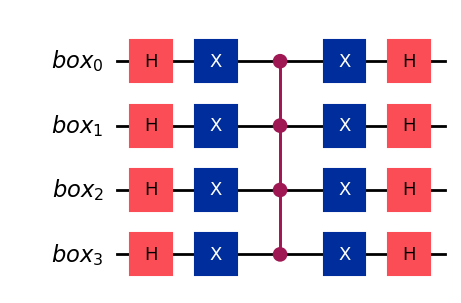

In [3]:
boxes = QuantumRegister(4, "box")
diffuser = QuantumCircuit(boxes)

# First layer of H gates
diffuser.h(boxes)
# Z_or gate
diffuser.x(boxes)
mcz = ZGate().control(3)
diffuser.append(mcz, [boxes[0], boxes[1], boxes[2], boxes[3]])
diffuser.x(boxes)
# Second layer of H gates
diffuser.h(boxes)

display(diffuser.draw("mpl"))

dif = diffuser.to_gate()
dif.name = "diffuser"

# Building the Oracle

In the context of a sudoku, winners can be thought of as combinations that are valid sudoku, and losers are those that are not valid. In other words, winners are combinations where the numbers in each row and column are unique.

In Grover's Algorithm, the oracle turns winners negative and leave losers as they are.  Losers are those who are not. We can achieve this by making use of the phase kickback phenomenon.

After doing this, we have to revert the checks qubits to |0000⟩, so that the interference in quantum states caused by the diffuser (which will be added later) will not be hindered.

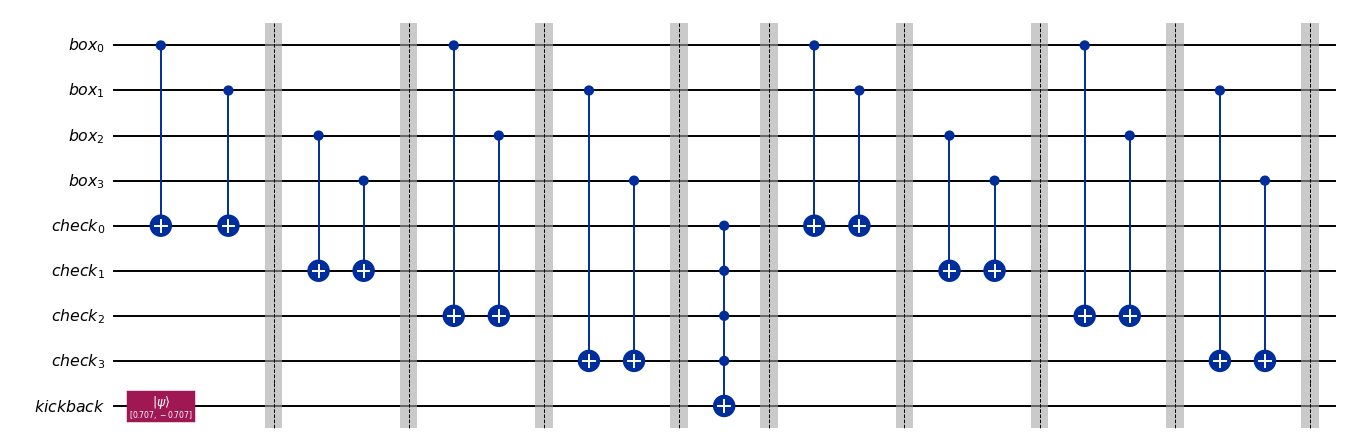

In [4]:
# Creating the necessary quantum registers
boxes = QuantumRegister(4, "box")
checks = QuantumRegister(4, "check")
kickback = QuantumRegister(1, "kickback")
# Creating the quantum circuit using these registers
oracle = QuantumCircuit(boxes, checks, kickback)
# Initialize kickback qubit to be |->
oracle.initialize([1/np.sqrt(2), -1/np.sqrt(2)], kickback)

# Boxes in each row and each column
listOfChecks = [[0, 1], [2, 3], [0, 2], [1, 3]]
# Flip the check qubit to 1 if the numbers in the corresponding row/column is unique
for i, check in enumerate(listOfChecks):
  oracle.cx(boxes[check[0]], checks[i])
  oracle.cx(boxes[check[1]], checks[i])
  oracle.barrier()

# Trigger the phase kickback phenomenon if every row and column is unique
oracle.mcx([checks[0], checks[1], checks[2], checks[3]], kickback)
oracle.barrier()

# Reverting checks qubits back to |0000>
for i, check in enumerate(listOfChecks):
  oracle.cx(boxes[check[0]], checks[i])
  oracle.cx(boxes[check[1]], checks[i])
  oracle.barrier()


display(oracle.draw("mpl", scale = 0.7, fold = -1))

ora = oracle.to_instruction()
ora.name = "oracle"

# Creating the Grover's Circuit


### Grover's Algorithm Architecture

In general, for Grover's algorithm a layer of H gates is first applied. In this context, a layer of H gates is applied to all the boxes quantum register. This will result in a uniform superposition of all possible permutations |u⟩.

$$
|u⟩ = \dfrac{1}{\sqrt{16}}|0000⟩ + \dfrac{1}{\sqrt{16}}|0001⟩ + \dfrac{1}{\sqrt{16}}|0010⟩ \,+ \,\,... + \dfrac{1}{\sqrt{16}}|1111⟩
$$


Afterwards, the oracle and diffuser is applied repeatedly for a chosen t number of times. We call the merged oracle and diffuser gate G.


$$
G^t = ((\text{diffuser})(\text{oracle}))^t
$$

We have already constucted the oracle and diffuser blocks previously. Now, we need to choose the number of times we iterate G.

### Choosing the number of iterations


We know that after applying G t number of times to |u⟩, we get
$$
G^t|u\rangle = \cos((2t+1)θ) \,|L⟩ + \sin((2t+1)\,θ)|W⟩
\\ \text{where} \,\, θ= \sin^{-1}\left(\sqrt{\dfrac{|W|}{N}}\right)
$$

To maximise the probability of measuring a winner combination at the end, we choose t such that $\sin((2t+1)θ)$ is as close to 1 as posssible. We can achieve this by choosing t to be

$$
t = \left\lfloor\frac{\pi}{4θ}\right\rfloor
$$

Therefore, to calculate the number of iterations t, we need to find the value of $θ$. This can be done through the formula $θ= \sin^{-1}\left(\sqrt{\dfrac{|W|}{N}}\right)$. N is obviously $2^4 = 16$. By checking all the 16 possibities, we realise that only 2 of them are winners, namely 0110 and 1001. Thus, $θ= \sin^{-1}\left(\sqrt{\dfrac{2}{16}}\right)$ Substituting in this value of θ, we get t = 2.

With this choice of t, we can calculate the probability that we will get a winner combination upon measurement. This is given by $\sin^2((2t+1)θ) = 0.94531$

### Constructing Grover's Circuit with two iterations

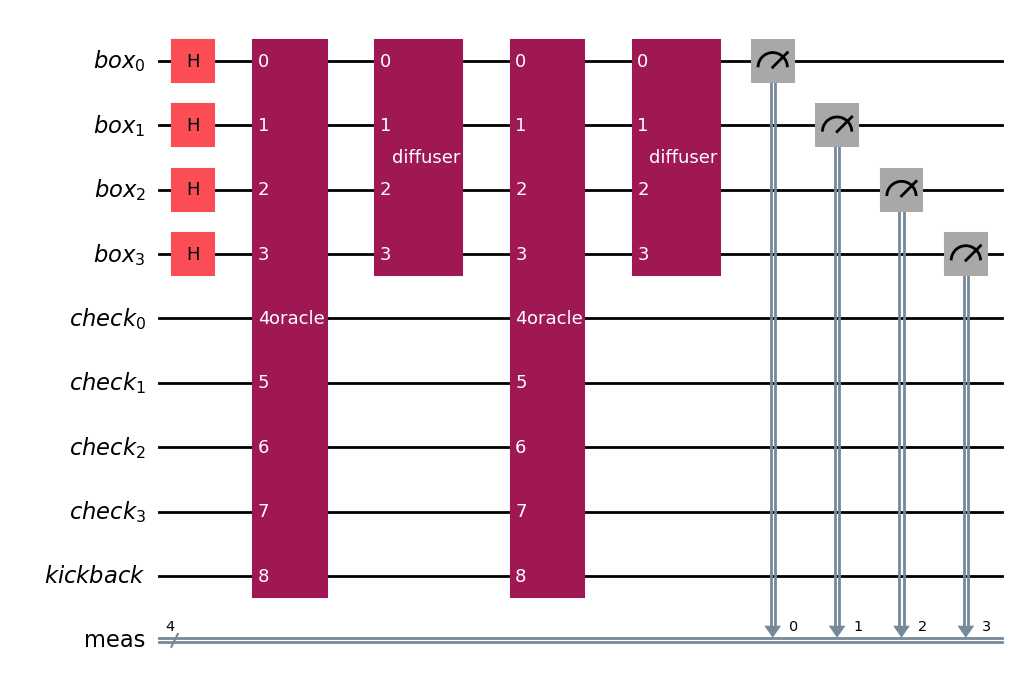

In [5]:
boxes = QuantumRegister(4, "box")
checks = QuantumRegister(4, "check")
kickback = QuantumRegister(1, "kickback")
result = ClassicalRegister(4, "meas")
groverCircuit = QuantumCircuit(boxes, checks, kickback, result)

# Apply H gate to all boxes
groverCircuit.h(boxes)
# First iteration of G
groverCircuit.append(ora, list(boxes) + list(checks) + list(kickback))
groverCircuit.append(dif, list(boxes))
# Second iteration of G
groverCircuit.append(ora, list(boxes) + list(checks) + list(kickback))
groverCircuit.append(dif, list(boxes))

groverCircuit.measure(boxes, result)

display(groverCircuit.draw("mpl"))

# Running the circuit

### Using a simulator


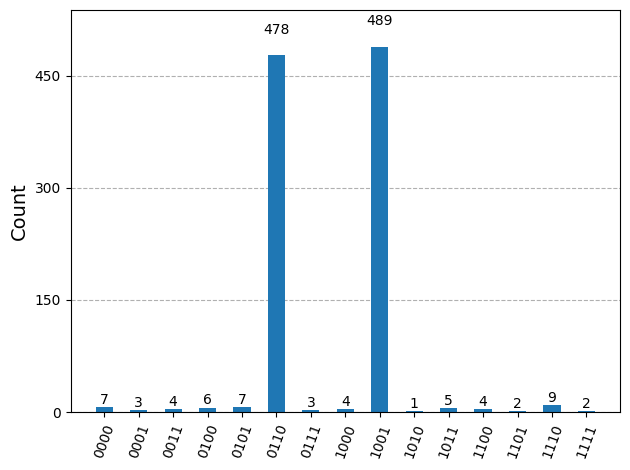

In [6]:
grover_compiled = transpile(groverCircuit, AerSimulator())
result = AerSimulator().run(grover_compiled).result()
statistics = result.get_counts()
display(plot_histogram(statistics))



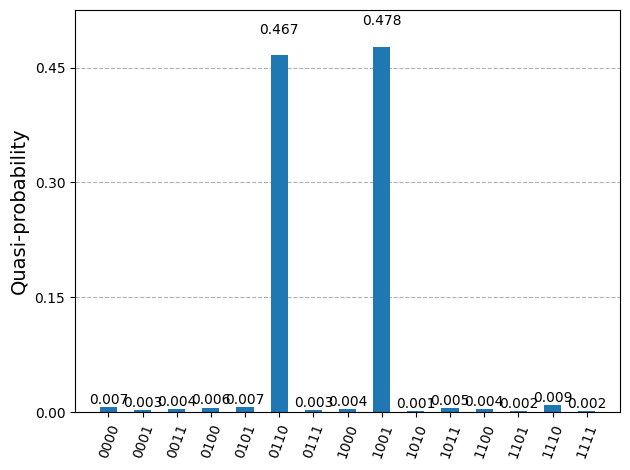

In [7]:
shots = sum(statistics.values())
probabilities = {state : count / shots for state, count in statistics.items()}
display(plot_histogram(probabilities))

### Evaluating Results

The simulator gives a probability of measuring a winner combination to be 0.945. This is very close to the theoretical value of 0.94531.

### Using IBM's quantum computer

In [8]:
!pip install qiskit-ibm-runtime
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

In [9]:
from google.colab import userdata

token = userdata.get("IBM_QUANTUM_TOKEN")
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=token,
    overwrite=True
)


service = QiskitRuntimeService()
'''backend = service.least_busy(
    simulator=False,
    operational=True
)'''
backend = service.backend("ibm_kingston")

qiskit_runtime_service.__init__:WARNING:2026-07-23 12:06:07,657: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: jgjg. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-07-23 12:06:07,665: Using instance: jgjg, plan: open


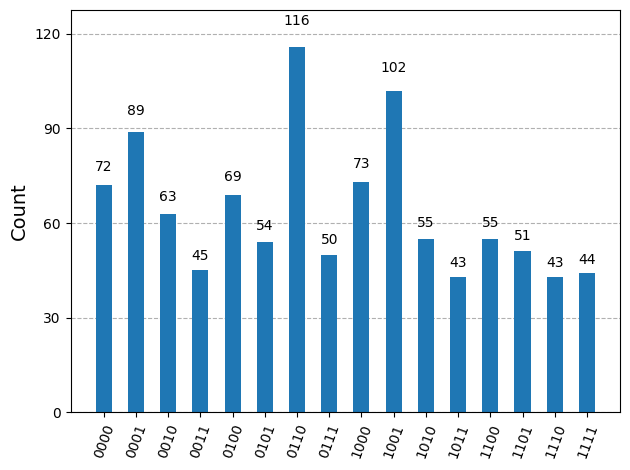

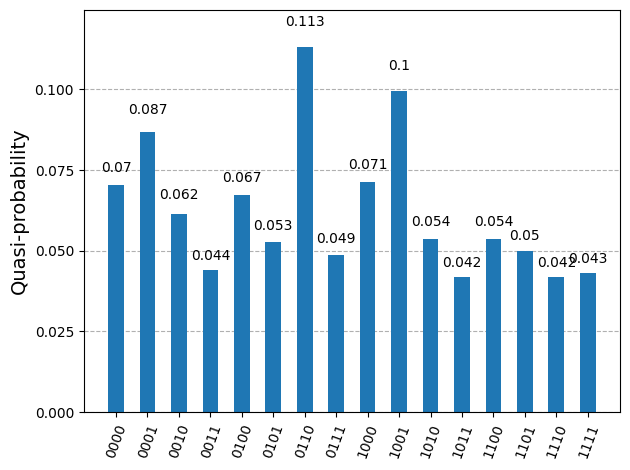

In [10]:
grover_compiled = transpile(groverCircuit, backend)
sampler = Sampler(backend)
result = sampler.run([grover_compiled], shots=1024).result()
statistics = result[0].data.meas.get_counts()
display(plot_histogram(statistics))

probabilities = {state : count / 1024 for state, count in statistics.items()}
display(plot_histogram(probabilities))

### Evaluating Results

When ran on IBM's Quantum Computer, the probability that we got a winner combination when measured is 0.213. This is significantly lower than the theoretical value. We can attibute this disparity due to noise in the quantum computer hardware.